### What Are Vector Embeddings & its Visualization?
Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Simplified 2D example (real embeddings have hundreds of dimensions or features)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15],
    "youtube": [0.2, 0.5],
    "google": [0.25, 0.45]
}

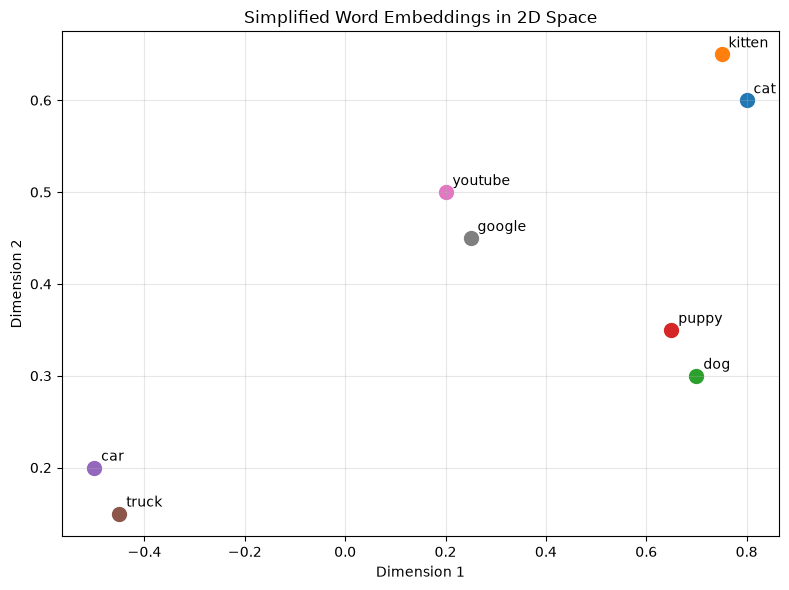

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Measuring Similarity

In [10]:
# Cosine similarity
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product = np.dot(vec1,vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

In [11]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity = cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [12]:
cat_car_similarity = cosine_similarity(cat_vector,car_vector)
print(cat_car_similarity)

-0.43718588548916804


### Creating Your First Embeddings

- Using Huggingface open source models, sentence-transformers/all-MiniLM-L6-v2 - https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

- Langchain Huggingface - https://reference.langchain.com/python/langchain-huggingface/embeddings/huggingface/HuggingFaceEmbeddings

In [1]:
# using Huggingface
from langchain_huggingface import HuggingFaceEmbeddings

## Initialize a simple Embedding model(no API Key needed!)
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embeddings

/Users/pshekarappa/pravn27/eng-it-career/full-stack-data-ai/rag/rag-learning-journey/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 20376.06it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [2]:
## create your first embeddings
text = "Hello, I am learning about Vector embeddings and study, applying & building RAG system"

emb_text = embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length : {len(emb_text)}")
print(emb_text)

Text: Hello, I am learning about Vector embeddings and study, applying & building RAG system
Embedding length : 384
[-0.04901539161801338, 0.007250844966620207, 0.0029063515830785036, -0.06357124447822571, -0.035020098090171814, 0.014469633810222149, -0.05213354900479317, 0.03715166077017784, -0.054254915565252304, -0.00625403318554163, -0.013470274396240711, 0.04093340039253235, 0.05833343043923378, 0.012141077779233456, -0.07636534422636032, 0.04675005376338959, 0.02987416461110115, 0.16086933016777039, -0.004720628261566162, 0.023000016808509827, -0.06636032462120056, 0.0040261223912239075, 0.0016282994765788317, -0.09796345978975296, 0.03503061458468437, 0.016704745590686798, 0.005125067662447691, 0.012275706976652145, 0.11023296415805817, -0.0633573830127716, 0.04172175005078316, 0.02346230484545231, 0.012093338184058666, 0.030444102361798286, -0.10123808681964874, 0.10175173729658127, 0.009956520982086658, 0.05093838647007942, -0.11062049120664597, 0.05933493748307228, -0.0230210

In [ ]:
sentences = [
    "The cat sat on the mat",
    "i m in study, understand, & building RAG system",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence = embeddings.embed_documents(sentences)

print(f"Total Embedding outcome: {embedding_sentence}")
print(embedding_sentence[0])
print(embedding_sentence[1])

Total Embedding outcome: [[0.1304018348455429, -0.011870141141116619, -0.028117015957832336, 0.051238663494586945, -0.05597453936934471, 0.030191563069820404, 0.03016134724020958, 0.02469828724861145, -0.018370578065514565, 0.05876677483320236, -0.024953190237283707, 0.060154203325510025, 0.039831679314374924, 0.033230528235435486, -0.06131145730614662, -0.049373120069503784, -0.05486353114247322, -0.04007609188556671, 0.056429170072078705, 0.03915657848119736, -0.03473708778619766, -0.013247725553810596, 0.03196621313691139, -0.06349916756153107, -0.06017855927348137, 0.07823455333709717, -0.02830391377210617, -0.047442805022001266, 0.04035932198166847, -0.006630933377891779, -0.0667409896850586, -0.004191323183476925, -0.025311654433608055, 0.05334170162677765, 0.017428040504455566, -0.09792359173297882, 0.006061278749257326, -0.06524160504341125, 0.045572567731142044, 0.02364187128841877, 0.07658479362726212, -0.010264384560286999, -0.00407679658383131, -0.06232280284166336, 0.03370

In [7]:
# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")

📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

